# Lecture 3a — What Diversification Actually Does

### The claim on trial

> **"Diversification reduces risk."**

Nobody disputes this. It is the one piece of investment advice that every regulator,
textbook and financial adviser agrees on. So we are not going to argue with it — we are
going to ask the sharper question:

> **By how much, and what stops it going further?**

The answer turns out to be surprisingly hard-edged. Diversification does not reduce risk
indefinitely; it runs into a floor, that floor is set by the *average correlation* between
your assets, and no amount of adding more stocks will break through it. Understanding
exactly where that floor sits is what makes the next two notebooks — where we let an
optimiser and then a machine learning algorithm attack the problem — make any sense at all.

### What you will be able to do afterwards

1. Explain why portfolio **return** is a simple average of asset returns but portfolio
   **risk** is not, and why that asymmetry is the entire subject.
2. Compute portfolio variance from weights and a covariance matrix, and read the sector
   block structure in a real correlation matrix.
3. Derive and *see* the **diversification floor**: the level of risk you cannot get below
   by adding more assets.
4. Distinguish an asset's **weight** in a portfolio from its **contribution to risk** —
   and show that an equally weighted portfolio is not equally risky.
5. Build inverse-volatility and naive risk-parity portfolios without any optimiser.

No optimisation in this notebook. We are building the intuition that Lecture 3b will then
use to explain why optimisation disappoints.

Same two-layer format as before: narrative in the text, mathematics in the collapsible
boxes, skip them if you prefer.

---

## 0. Setup

Run once. Works on Colab, local Anaconda and JupyterHub. We reuse the same public S&P 500
dataset as Lecture 2, plus the constituents file, which gives us each company's **GICS
sector** — and sector labels are going to turn out to matter a great deal.

In [1]:
# =====================================================================
#  AIRM Lecture 3a — bootstrap.  Run once.
# =====================================================================
import sys, subprocess, urllib.request, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

def ensure(pkgs):
    missing = []
    for p in pkgs:
        mod = {"scikit-learn": "sklearn"}.get(p, p)
        try: __import__(mod)
        except ImportError: missing.append(p)
    if missing:
        print(f"Installing {', '.join(missing)} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

ensure(["pandas", "numpy", "plotly"])

import numpy as np, pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB: pio.renderers.default = "colab"
np.random.seed(3)

AIRM_TEMPLATE = "plotly_white"
AIRM_COLOURS  = ["#1b4965", "#c1121f", "#5fa8d3", "#e09f3e", "#606c38", "#8e7dbe"]
TRADING_DAYS  = 252

# --- data ------------------------------------------------------------
DATA_DIR = Path("airm_data"); DATA_DIR.mkdir(exist_ok=True)
SOURCES = {
    "prices.csv":       "https://raw.githubusercontent.com/plotly/datasets/master/all_stocks_5yr.csv",
    "constituents.csv": "https://raw.githubusercontent.com/datasets/s-and-p-500-companies/main/data/constituents.csv",
}
def fetch(name):
    path = DATA_DIR / name
    if not path.exists():
        print(f"Downloading {name} ...", end=" ")
        urllib.request.urlretrieve(SOURCES[name], path); print("done")
    return path

_raw = pd.read_csv(fetch("prices.csv"), parse_dates=["date"]).rename(columns={"Name": "ticker"})
_con = pd.read_csv(fetch("constituents.csv"))

prices_all = _raw.pivot_table(index="date", columns="ticker", values="close")
SECTOR = _con.set_index("Symbol")["GICS Sector"].to_dict()

def annualise_vol(daily_vol):  return daily_vol * np.sqrt(TRADING_DAYS)
def annualise_ret(daily_ret):  return daily_ret * TRADING_DAYS

print(f"\nReady. {prices_all.shape[1]} stocks, "
      f"{prices_all.index.min():%b %Y} to {prices_all.index.max():%b %Y}")


Ready. 505 stocks, Feb 2013 to Feb 2018


In [2]:
# Build a sector-balanced universe: the N most heavily traded names in each GICS sector.
# Balance matters -- a universe of 40 tech stocks would badly overstate correlation.
PER_SECTOR = 4

_liquidity = _raw.groupby("ticker")["volume"].mean()
_eligible = [t for t in prices_all.columns
             if t in SECTOR and prices_all[t].notna().all()]

universe = []
for s in sorted({SECTOR[t] for t in _eligible}):
    names = [t for t in _eligible if SECTOR[t] == s]
    universe += list(_liquidity[names].nlargest(PER_SECTOR).index)

# Keep tickers grouped by sector -- this ordering makes the heatmap readable later.
universe = sorted(universe, key=lambda t: (SECTOR[t], t))
prices = prices_all[universe]
returns = prices.pct_change(fill_method=None).dropna()

sector_of = pd.Series({t: SECTOR[t] for t in universe})
print(f"Universe: {len(universe)} stocks across {sector_of.nunique()} sectors, "
      f"{len(returns)} trading days")
print(sector_of.value_counts().sort_index().to_string())

Universe: 44 stocks across 11 sectors, 1258 trading days
Communication Services    4
Consumer Discretionary    4
Consumer Staples          4
Energy                    4
Financials                4
Health Care               4
Industrials               4
Information Technology    4
Materials                 4
Real Estate               4
Utilities                 4


---

## 1. Why risk is the interesting half

Suppose you split your money across $N$ assets with weights $w_1 \dots w_N$ summing to 1.
The portfolio's return is boring:

$$r_p = \sum_i w_i r_i$$

A weighted average, nothing more. If you hold half Apple and half Exxon, you get half of
each return. There is no cleverness available here.

The portfolio's *risk* is a different animal entirely, because risk does not add up. Two
assets that each swing 30% a year can combine into a portfolio that swings 20% — or 30%, or
almost 0% — depending entirely on **how they move together**. That single fact is why
portfolio construction is a discipline rather than an arithmetic exercise.

Let us see it immediately.

In [3]:
def portfolio_stats(weights, rets, annualise=True):
    """Return (expected return, volatility) of a fixed-weight portfolio.

    Computed from the covariance matrix rather than by simulating the portfolio path,
    because that is the form every optimiser works in.
    """
    w = np.asarray(weights, dtype=float)
    mu = rets.mean().values
    cov = rets.cov().values
    ret = w @ mu
    vol = np.sqrt(w @ cov @ w)
    if annualise:
        return annualise_ret(ret), annualise_vol(vol)
    return ret, vol


# Pick two stocks from very different sectors and compare them to a 50/50 blend.
a, b = "AAPL", "SO"          # a technology name and a utility
pair = returns[[a, b]]

for label, w in [(f"100% {a}", [1, 0]), (f"100% {b}", [0, 1]), ("50/50 blend", [0.5, 0.5])]:
    r, v = portfolio_stats(w, pair)
    print(f"{label:14s}  return {r:6.2%}   volatility {v:6.2%}")

rho = pair.corr().iloc[0, 1]
avg_vol = annualise_vol(pair.std()).mean()
_, blend_vol = portfolio_stats([0.5, 0.5], pair)
print(f"\nCorrelation between {a} and {b}: {rho:.2f}")
print(f"Average of the two volatilities : {avg_vol:.2%}")
print(f"Volatility of the 50/50 blend   : {blend_vol:.2%}   <-- LOWER than either average")
print("\nThe return was a plain average. The risk was not. That gap is 'diversification'.")

100% AAPL       return 19.81%   volatility 23.17%
100% SO         return  0.84%   volatility 14.67%
50/50 blend     return 10.33%   volatility 14.29%

Correlation between AAPL and SO: 0.10
Average of the two volatilities : 18.92%
Volatility of the 50/50 blend   : 14.29%   <-- LOWER than either average

The return was a plain average. The risk was not. That gap is 'diversification'.


<details>
<summary><b>The portfolio variance formula</b></summary>

For weights $w$ and covariance matrix $\Sigma$, the portfolio variance is

$$\sigma_p^2 = w^\top \Sigma w = \sum_i \sum_j w_i w_j \sigma_{ij}
= \underbrace{\sum_i w_i^2 \sigma_i^2}_{\text{own variances}}
+ \underbrace{\sum_{i \neq j} w_i w_j \sigma_i \sigma_j \rho_{ij}}_{\text{co-movement}}$$

The second term is where all the action is. With $N$ assets there are $N$ variance terms and
$N(N-1)$ covariance terms — so as the portfolio grows, the covariances overwhelmingly
dominate. For 44 assets that is 44 variances against 1,892 covariances.

Two consequences follow, and both matter later:

1. **Risk is driven by co-movement, not by individual volatility.** Picking "safe" stocks
   one at a time is not a portfolio strategy.
2. **The covariance matrix is mostly covariances**, each estimated with error. Lecture 3b
   is about what that error does to you.

</details>

## 2. The diversification curve

Now the central picture of this notebook. Take two assets, vary the weight from 100% in one
to 100% in the other, and plot every resulting portfolio in risk–return space. The shape of
that curve depends **entirely** on the correlation between them.

Drag the slider. At $\rho = +1$ the curve is a straight line — no diversification benefit
at all. As $\rho$ falls the curve bows leftward, and the bow *is* the benefit. At
$\rho = -1$ it reaches the vertical axis: a perfectly hedged, zero-risk portfolio.

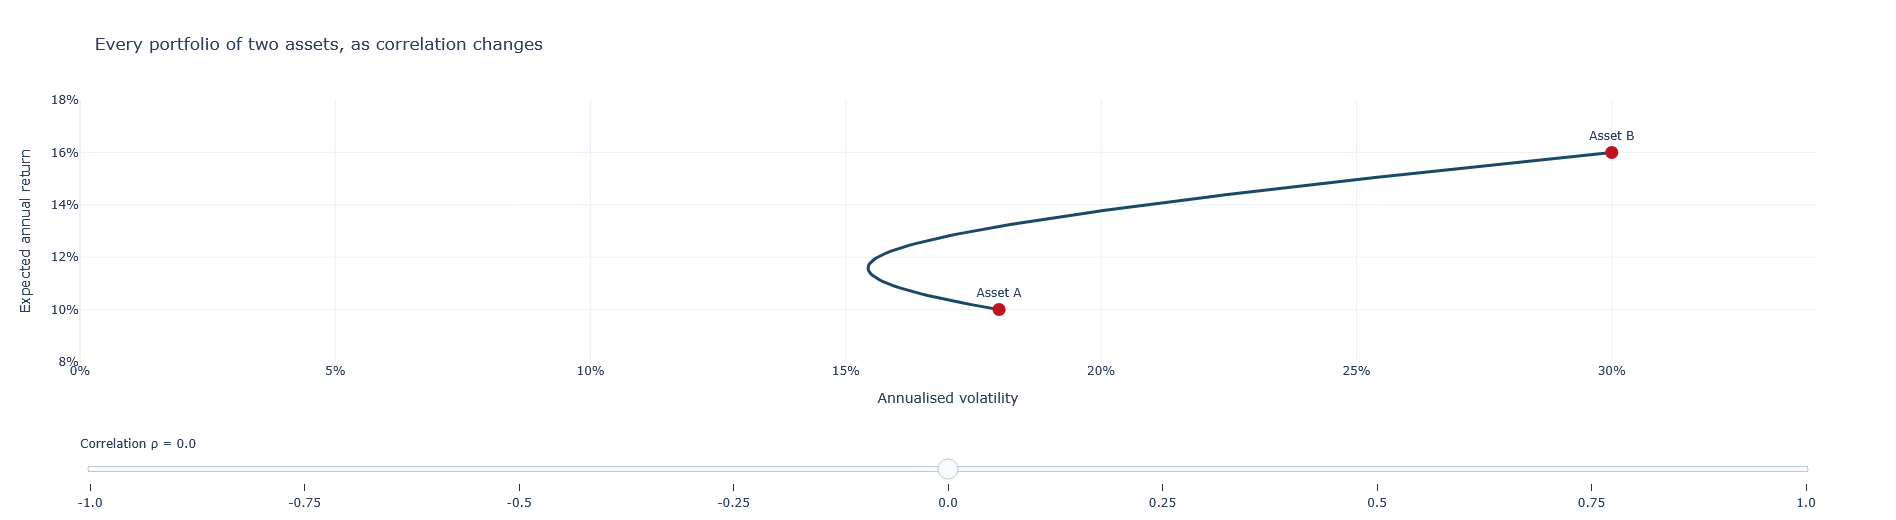

In [4]:
# Two synthetic assets so we can control the correlation exactly.
mu_A, sig_A = 0.10, 0.18      # lower return, lower risk
mu_B, sig_B = 0.16, 0.30      # higher return, higher risk
w_grid = np.linspace(0, 1, 101)
rho_grid = np.round(np.arange(-1.0, 1.01, 0.25), 2)

fig = go.Figure()
for k, rho_ in enumerate(rho_grid):
    cov_AB = rho_ * sig_A * sig_B
    vols = np.sqrt((w_grid * sig_A)**2 + ((1 - w_grid) * sig_B)**2
                   + 2 * w_grid * (1 - w_grid) * cov_AB)
    rets = w_grid * mu_A + (1 - w_grid) * mu_B
    fig.add_trace(go.Scatter(x=vols, y=rets, mode="lines", name=f"ρ = {rho_}",
                             visible=(rho_ == 0.0),
                             line=dict(color=AIRM_COLOURS[0], width=3),
                             hovertemplate="vol %{x:.1%}<br>return %{y:.1%}<extra></extra>"))

# The two endpoints never move, so plot them once as fixed reference points.
fig.add_trace(go.Scatter(x=[sig_A, sig_B], y=[mu_A, mu_B], mode="markers+text",
                         text=["Asset A", "Asset B"], textposition="top center",
                         marker=dict(size=13, color=AIRM_COLOURS[1]),
                         showlegend=False, hoverinfo="skip"))

steps = []
for k, rho_ in enumerate(rho_grid):
    vis = [False] * len(rho_grid) + [True]
    vis[k] = True
    steps.append(dict(label=f"{rho_}", method="update", args=[{"visible": vis}]))

fig.update_layout(
    title="Every portfolio of two assets, as correlation changes",
    template=AIRM_TEMPLATE, height=520, showlegend=False,
    xaxis=dict(title="Annualised volatility", tickformat=".0%", range=[0, 0.34]),
    yaxis=dict(title="Expected annual return", tickformat=".0%", range=[0.08, 0.18]),
    sliders=[dict(active=int(np.where(rho_grid == 0.0)[0][0]), pad=dict(t=70),
                  currentvalue=dict(prefix="Correlation ρ = "), steps=steps)])
fig.show()

Three things to take from that slider, because each one returns later:

**The bow is the free lunch.** At any $\rho < 1$ there exist portfolios with *less risk than
either asset alone*. Nothing was given up to get it — that is why diversification is the
closest thing to a free lunch in finance.

**Low correlation is worth more than low volatility.** A high-risk asset with low
correlation to your portfolio can *reduce* your total risk. This is why an asset must never
be judged in isolation, only by what it does to the whole.

**The benefit is bounded by $\rho$, and $\rho$ is a real number you do not control.** Real
equities sit around 0.2–0.5 with each other. So the bow is real but modest, and — crucially
— $\rho$ has to be *estimated*. Hold that thought.

<details>
<summary><b>The minimum-variance combination of two assets</b></summary>

Differentiating $\sigma_p^2 = w^2\sigma_A^2 + (1-w)^2\sigma_B^2 + 2w(1-w)\rho\sigma_A\sigma_B$
with respect to $w$ and setting it to zero gives

$$w^*_A = \frac{\sigma_B^2 - \rho\,\sigma_A\sigma_B}{\sigma_A^2 + \sigma_B^2 - 2\rho\,\sigma_A\sigma_B}$$

Two special cases are worth committing to memory. When $\rho = 1$ the expression collapses
and no interior minimum exists — the least risky portfolio is simply 100% of the
lower-volatility asset. When $\rho = -1$, choosing
$w^*_A = \sigma_B / (\sigma_A + \sigma_B)$ gives $\sigma_p = 0$ **exactly**: a riskless
portfolio out of two risky assets.

Notice that $w^*$ depends on $\rho$ and on both volatilities. Every one of those is an
estimate. This formula is the two-asset ancestor of the full Markowitz optimiser, and it
inherits the same fragility.

</details>

## 3. Correlation has structure

So correlation drives everything. What does it actually look like across 44 real stocks?

The trick is the **ordering**. Sorted alphabetically, a correlation matrix looks like
random mush. Sorted by sector — which is how we built the universe — the structure jumps
out. Use the buttons to switch between the correlation matrix, the covariance matrix, and
the alphabetical scramble.

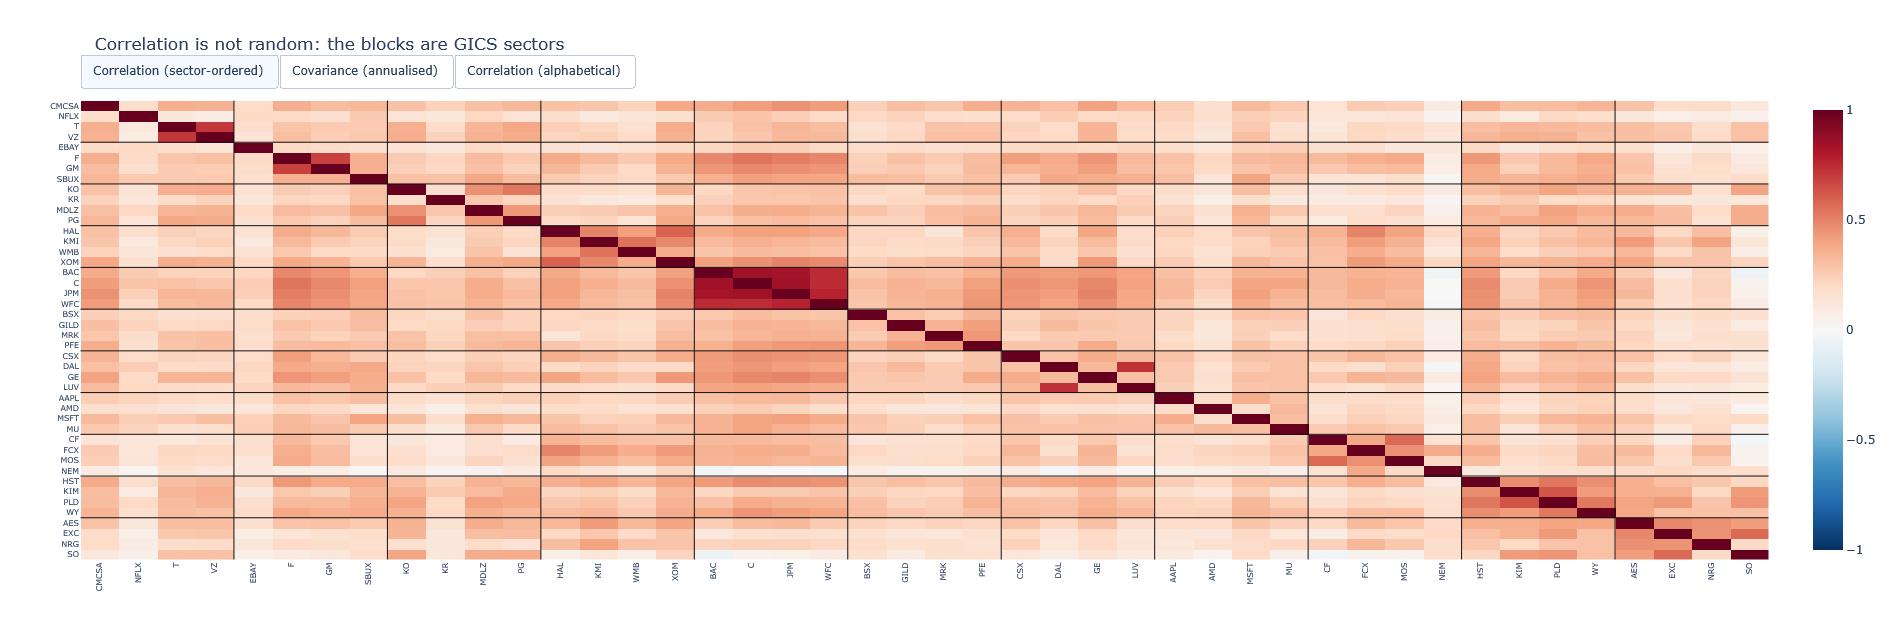

In [5]:
corr = returns.corr()
cov_ann = returns.cov() * TRADING_DAYS          # annualised, so numbers are readable
alpha_order = sorted(universe)
corr_alpha = returns[alpha_order].corr()

# Sector boundaries, for drawing block lines on the sector-ordered view.
sector_seq = [SECTOR[t] for t in universe]
bounds = [i for i in range(1, len(universe)) if sector_seq[i] != sector_seq[i-1]]

panels = [
    ("Correlation (sector-ordered)", corr,       "RdBu_r", -1, 1,  universe),
    ("Covariance (annualised)",      cov_ann,    "RdBu_r", -0.06, 0.06, universe),
    ("Correlation (alphabetical)",   corr_alpha, "RdBu_r", -1, 1,  alpha_order),
]

fig = go.Figure()
for i, (label, mat, scale, lo, hi, order) in enumerate(panels):
    fig.add_trace(go.Heatmap(z=mat.values, x=order, y=order, visible=(i == 0),
                             colorscale=scale, zmin=lo, zmax=hi,
                             colorbar=dict(title=""), hoverongaps=False))

shapes = []
for b in bounds:
    shapes += [dict(type="line", x0=b-0.5, x1=b-0.5, y0=-0.5, y1=len(universe)-0.5,
                    line=dict(color="#111", width=1)),
               dict(type="line", y0=b-0.5, y1=b-0.5, x0=-0.5, x1=len(universe)-0.5,
                    line=dict(color="#111", width=1))]

fig.update_layout(
    title="Correlation is not random: the blocks are GICS sectors",
    template=AIRM_TEMPLATE, height=640, shapes=shapes,
    xaxis=dict(tickangle=-90, tickfont=dict(size=8)),
    yaxis=dict(tickfont=dict(size=8), autorange="reversed"),
    updatemenus=[dict(type="buttons", direction="right", x=0, y=1.10, xanchor="left",
        buttons=[dict(label=lab, method="update",
                      args=[{"visible": [j == i for j in range(len(panels))]},
                            {"shapes": shapes if i != 2 else []}])
                 for i, (lab, *_ ) in enumerate(panels)])])
fig.show()

In [6]:
# Quantify the block structure.
same_sector = np.array([[SECTOR[x] == SECTOR[y] for y in universe] for x in universe])
offdiag = ~np.eye(len(universe), dtype=bool)

within = corr.values[same_sector & offdiag].mean()
across = corr.values[~same_sector & offdiag].mean()

print(f"Average correlation WITHIN a sector : {within:.3f}")
print(f"Average correlation ACROSS sectors  : {across:.3f}")
print(f"Overall average pairwise correlation: {corr.values[offdiag].mean():.3f}")
n_pairs = len(universe) * (len(universe) - 1) // 2
n_negative = int((corr.values[offdiag] < 0).sum() // 2)
print(f"\nRange of pairwise correlations: {corr.values[offdiag].min():.3f} "
      f"to {corr.values[offdiag].max():.3f}")
print(f"Negatively correlated pairs: {n_negative} out of {n_pairs} "
      f"({n_negative/n_pairs:.1%}), and the most negative is only "
      f"{corr.values[offdiag].min():.3f}")
print("\nSo there is effectively no hedge anywhere in this universe: nothing here")
print("reliably rises when the rest falls. That sets a hard floor on diversification.")

Average correlation WITHIN a sector : 0.416
Average correlation ACROSS sectors  : 0.254
Overall average pairwise correlation: 0.265

Range of pairwise correlations: -0.053 to 0.851
Negatively correlated pairs: 6 out of 946 (0.6%), and the most negative is only -0.053

So there is effectively no hedge anywhere in this universe: nothing here
reliably rises when the rest falls. That sets a hard floor on diversification.


Two observations, and the second is the important one.

**Sectors are real.** Within-sector correlation runs about 0.42 against 0.25 across
sectors — visible as blocks down the diagonal. This is not an artefact of how we chose the
stocks; it is the economic fact that utilities respond to different shocks than
semiconductors. In Lecture 3c a clustering algorithm will *rediscover* these blocks without
ever being shown a sector label, and we will use GICS as the answer key.

**There is no hedge here.** Only 6 of the 946 pairs are negatively correlated, and the most
negative of those reaches just −0.05 — statistically indistinguishable from zero. Not one
pair in this universe reliably rises when the others fall. In a bad month, everything falls
together. That is the fact which sinks naive expectations about diversification, and we can
now quantify exactly what it costs us.

## 4. The diversification floor

Here is the result that surprises people most.

Take $N$ assets, each with volatility $\sigma$, each pair correlated $\rho$, equally
weighted. The portfolio variance works out to

$$\sigma_p^2 = \frac{\sigma^2}{N} + \left(1 - \frac{1}{N}\right)\rho\,\sigma^2$$

Now let $N \to \infty$. The first term vanishes — that is the idiosyncratic risk being
diversified away, exactly as advertised. But the second term does **not** vanish. It
converges to $\rho\sigma^2$. So

$$\sigma_p \;\longrightarrow\; \sigma\sqrt{\rho}$$

**There is a floor, and correlation sets its height.** With $\rho = 0.28$ and $\sigma = 25\%$,
the floor is $25\% \times \sqrt{0.28} \approx 13\%$. You can own every stock in the world
and you will not get below it. Move the slider to feel how brutally $\rho$ controls the
outcome.

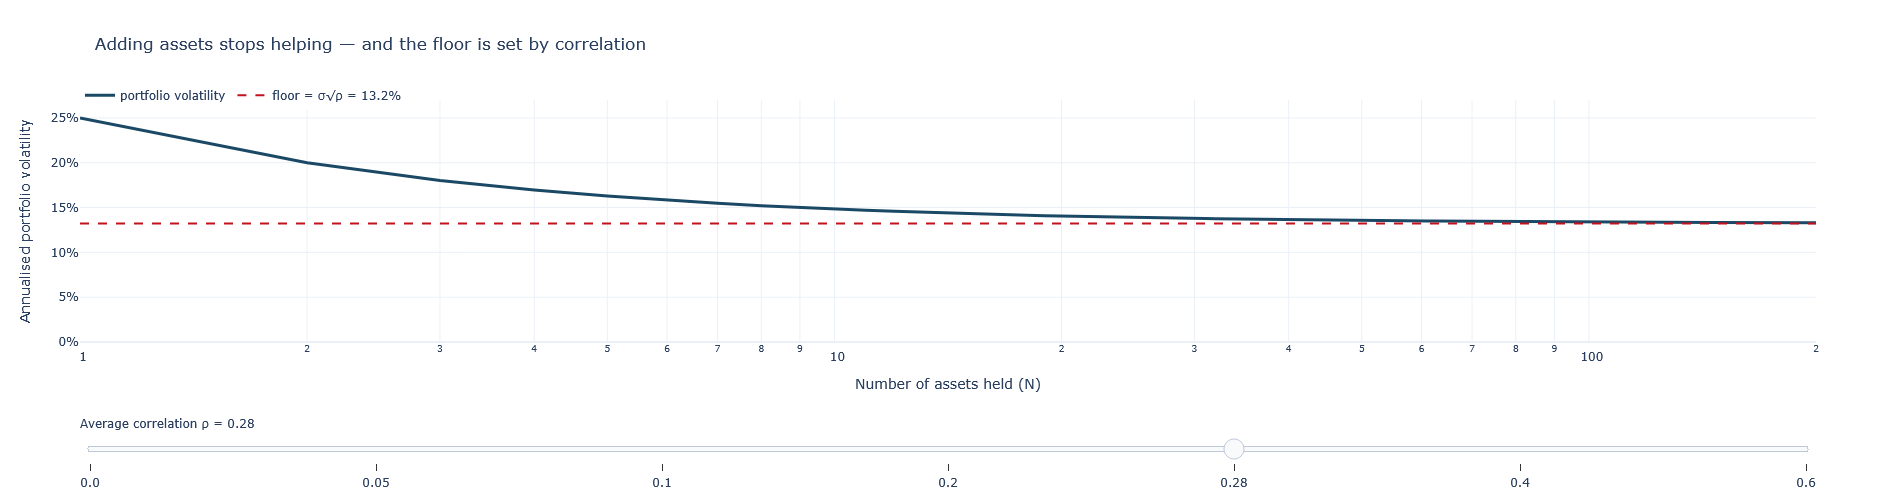

In [7]:
sigma_single = 0.25
n_grid = np.arange(1, 201)
rho_options = [0.0, 0.05, 0.1, 0.2, 0.28, 0.4, 0.6]

fig = go.Figure()
for k, rho_ in enumerate(rho_options):
    vols = sigma_single * np.sqrt(1/n_grid + (1 - 1/n_grid) * rho_)
    floor = sigma_single * np.sqrt(rho_)
    fig.add_trace(go.Scatter(x=n_grid, y=vols, mode="lines", visible=(rho_ == 0.28),
                             line=dict(color=AIRM_COLOURS[0], width=3),
                             name="portfolio volatility",
                             hovertemplate="N=%{x}<br>vol %{y:.1%}<extra></extra>"))
    fig.add_trace(go.Scatter(x=[1, 200], y=[floor, floor], mode="lines",
                             visible=(rho_ == 0.28),
                             line=dict(color=AIRM_COLOURS[1], width=2, dash="dash"),
                             name=f"floor = σ√ρ = {floor:.1%}"))

steps = []
for k, rho_ in enumerate(rho_options):
    vis = [False] * (2 * len(rho_options))
    vis[2*k] = vis[2*k + 1] = True
    steps.append(dict(label=f"{rho_}", method="update", args=[{"visible": vis}]))

fig.update_layout(
    title="Adding assets stops helping — and the floor is set by correlation",
    template=AIRM_TEMPLATE, height=500,
    xaxis=dict(title="Number of assets held (N)", type="log"),
    yaxis=dict(title="Annualised portfolio volatility", tickformat=".0%", range=[0, 0.27]),
    legend=dict(orientation="h", y=1.08),
    sliders=[dict(active=rho_options.index(0.28), pad=dict(t=70),
                  currentvalue=dict(prefix="Average correlation ρ = "), steps=steps)])
fig.show()

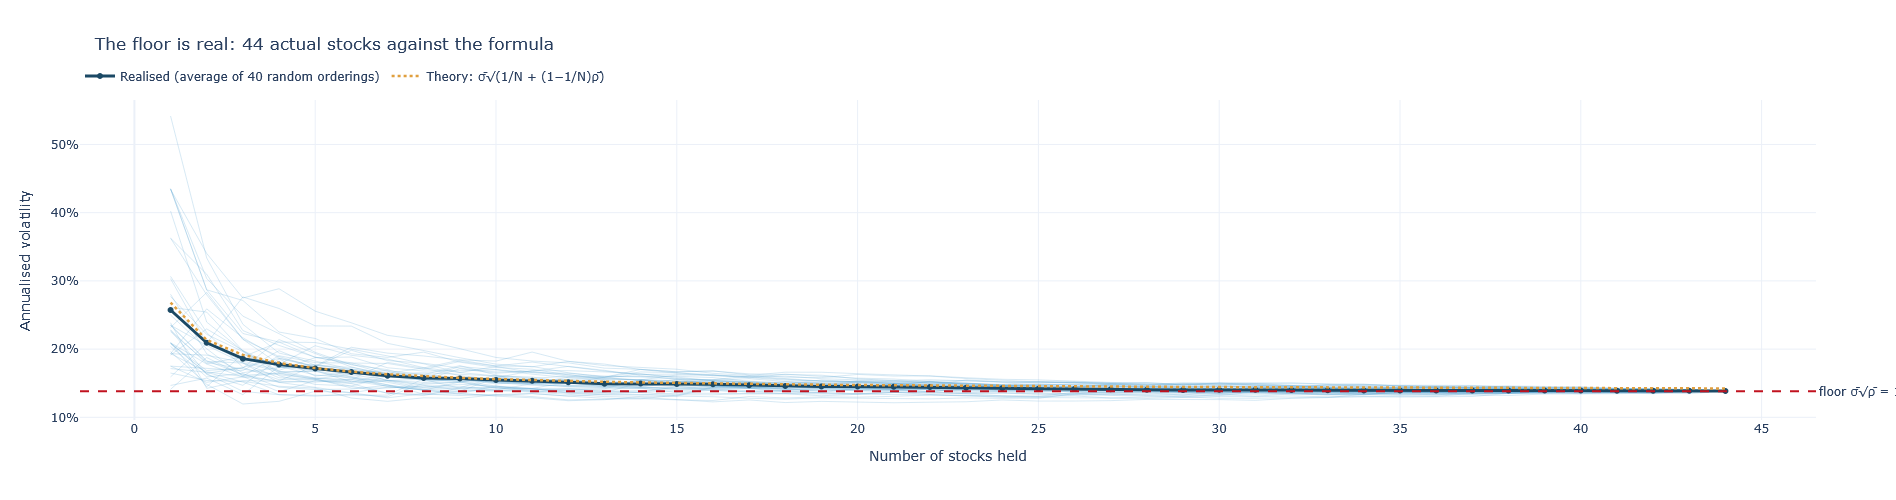

Average single-stock volatility : 26.8%
Average pairwise correlation    : 0.265
Predicted floor (σ̄√ρ̄)          : 13.8%
Realised with all 44 stocks     : 13.9%

Risk reduction from 1 stock to 44: 46%
Of the theoretically available reduction, captured by 10 stocks: 86%


In [8]:
# Does the theory hold on real data? Add stocks one at a time, in random order,
# and measure the volatility we actually realise.
rng = np.random.default_rng(3)
n_trials, max_n = 40, len(universe)
curves = np.full((n_trials, max_n), np.nan)

for t in range(n_trials):
    order = rng.permutation(universe)
    for n in range(1, max_n + 1):
        sub = returns[list(order[:n])]
        w = np.ones(n) / n
        curves[t, n-1] = annualise_vol(np.sqrt(w @ sub.cov().values @ w))

mean_curve = np.nanmean(curves, axis=0)
sigma_bar = annualise_vol(returns.std()).mean()
rho_bar = corr.values[offdiag].mean()
theory = sigma_bar * np.sqrt(1/np.arange(1, max_n+1) + (1 - 1/np.arange(1, max_n+1)) * rho_bar)
floor = sigma_bar * np.sqrt(rho_bar)

fig = go.Figure()
for t in range(n_trials):
    fig.add_trace(go.Scatter(x=np.arange(1, max_n+1), y=curves[t], mode="lines",
                             line=dict(color="rgba(95,168,211,0.25)", width=1),
                             showlegend=False, hoverinfo="skip"))
fig.add_trace(go.Scatter(x=np.arange(1, max_n+1), y=mean_curve, mode="lines+markers",
                         name="Realised (average of 40 random orderings)",
                         line=dict(color=AIRM_COLOURS[0], width=3)))
fig.add_trace(go.Scatter(x=np.arange(1, max_n+1), y=theory, mode="lines",
                         name="Theory: σ̄√(1/N + (1−1/N)ρ̄)",
                         line=dict(color=AIRM_COLOURS[3], width=2.5, dash="dot")))
fig.add_hline(y=floor, line=dict(color=AIRM_COLOURS[1], width=2, dash="dash"),
              annotation_text=f"floor σ̄√ρ̄ = {floor:.1%}", annotation_position="right")
fig.update_layout(title="The floor is real: 44 actual stocks against the formula",
                  template=AIRM_TEMPLATE, height=500,
                  xaxis_title="Number of stocks held", legend=dict(orientation="h", y=1.12),
                  yaxis=dict(title="Annualised volatility", tickformat=".0%"))
fig.show()

print(f"Average single-stock volatility : {sigma_bar:.1%}")
print(f"Average pairwise correlation    : {rho_bar:.3f}")
print(f"Predicted floor (σ̄√ρ̄)          : {floor:.1%}")
print(f"Realised with all {max_n} stocks     : {mean_curve[-1]:.1%}")
print(f"\nRisk reduction from 1 stock to {max_n}: {1 - mean_curve[-1]/mean_curve[0]:.0%}")
print(f"Of the theoretically available reduction, captured by 10 stocks: "
      f"{(mean_curve[0]-mean_curve[9])/(mean_curve[0]-floor):.0%}")

The formula tracks reality closely, and the practical lesson is in that last number:
**about ten stocks capture most of the diversification that is available at all.** Going
from 10 to 44 buys very little, because by then you are pressed against the floor. This is
the empirical basis for the old rule of thumb that a portfolio needs "20-odd names" — and
for the uncomfortable corollary that a fund holding 300 stocks is not meaningfully more
diversified than one holding 40, it is just harder to explain.

It also tells you where the remaining risk *goes*. Once idiosyncratic risk is gone, what is
left is the common factor — the market itself. You cannot diversify away the thing that
moves everything. Lecture 8 is about naming those factors; Lecture 6 is about surviving
them.

## 5. Your weights are not your risks

One more idea before we hand anything to an optimiser, and it is the one students most
often get wrong.

If you put 1/44 of your money into each of 44 stocks, you have equal *weights*. You do not
have equal *risk*. A volatile, highly correlated stock contributes far more to portfolio
risk than a quiet, independent one, even at identical weight.

The **risk contribution** of asset $i$ decomposes total portfolio volatility into per-asset
pieces that sum exactly to 100%.

In [9]:
def risk_contributions(weights, rets):
    """Decompose portfolio volatility into per-asset contributions (they sum to 1).

    RC_i = w_i * (Sigma w)_i / (w' Sigma w)
    """
    w = np.asarray(weights, dtype=float)
    cov = rets.cov().values
    port_var = w @ cov @ w
    return pd.Series(w * (cov @ w) / port_var, index=rets.columns)


w_eq = np.ones(len(universe)) / len(universe)
rc_eq = risk_contributions(w_eq, returns)

comparison = pd.DataFrame({
    "Weight": w_eq,
    "Risk contribution": rc_eq.values,
    "Volatility": annualise_vol(returns.std()).values,
}, index=universe)
comparison["Risk / weight"] = comparison["Risk contribution"] / comparison["Weight"]
comparison = comparison.sort_values("Risk contribution", ascending=False)

print("Equally weighted portfolio -- the five largest and smallest risk contributors:\n")
print(comparison.head(5).to_string(formatters={
    "Weight": "{:.2%}".format, "Risk contribution": "{:.2%}".format,
    "Volatility": "{:.1%}".format, "Risk / weight": "{:.2f}x".format}))
print("   ...")
print(comparison.tail(5).to_string(header=False, formatters={
    "Weight": "{:.2%}".format, "Risk contribution": "{:.2%}".format,
    "Volatility": "{:.1%}".format, "Risk / weight": "{:.2f}x".format}))

print(f"\nEvery weight is {w_eq[0]:.2%}. But risk contributions run from "
      f"{comparison['Risk contribution'].min():.2%} to {comparison['Risk contribution'].max():.2%} "
      f"-- a {comparison['Risk contribution'].max()/comparison['Risk contribution'].min():.1f}x spread.")

Equally weighted portfolio -- the five largest and smallest risk contributors:

    Weight Risk contribution Volatility Risk / weight
FCX  2.27%             5.27%      54.2%         2.32x
WMB  2.27%             4.07%      46.9%         1.79x
AMD  2.27%             4.05%      60.0%         1.78x
MU   2.27%             3.93%      43.5%         1.73x
NRG  2.27%             3.12%      40.2%         1.37x
   ...
VZ 2.27% 1.29% 16.5% 0.57x
T  2.27% 1.24% 15.9% 0.55x
PG 2.27% 1.12% 14.2% 0.49x
KO 2.27% 1.08% 14.1% 0.48x
SO 2.27% 0.71% 14.7% 0.31x

Every weight is 2.27%. But risk contributions run from 0.71% to 5.27% -- a 7.4x spread.


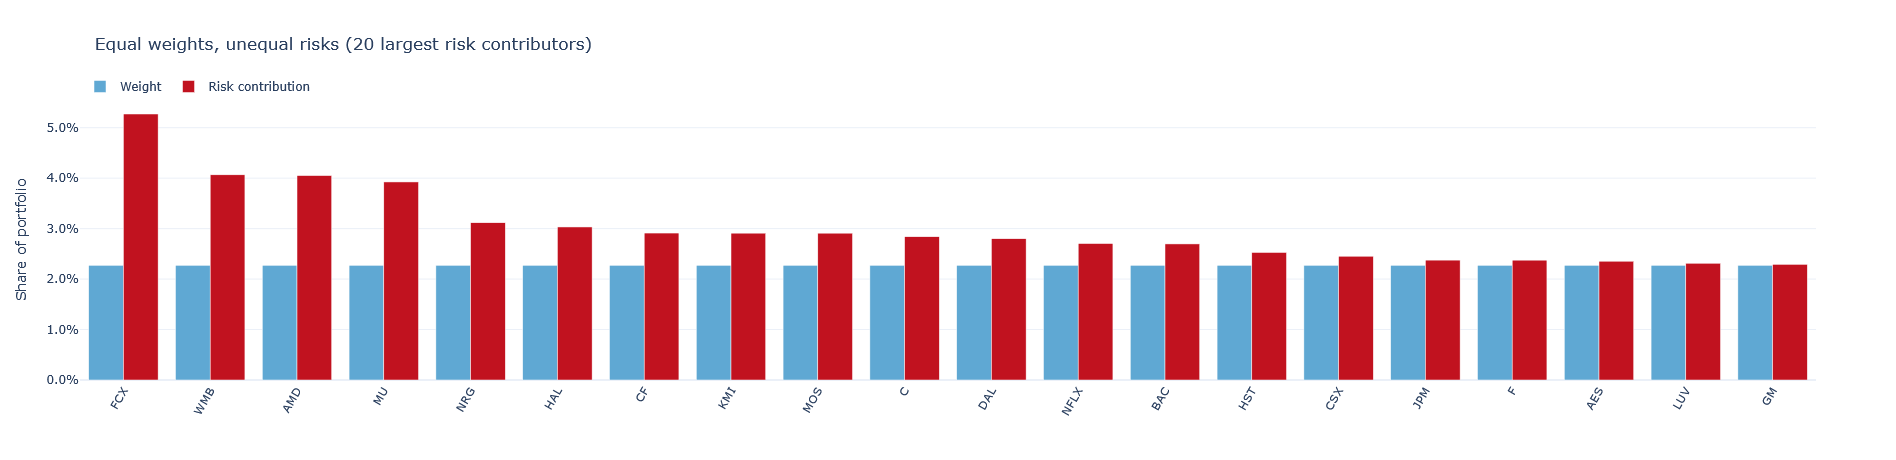

In [10]:
top = comparison.head(20)
fig = go.Figure()
fig.add_trace(go.Bar(x=top.index, y=top["Weight"], name="Weight",
                     marker_color=AIRM_COLOURS[2]))
fig.add_trace(go.Bar(x=top.index, y=top["Risk contribution"], name="Risk contribution",
                     marker_color=AIRM_COLOURS[1]))
fig.update_layout(
    title="Equal weights, unequal risks (20 largest risk contributors)",
    template=AIRM_TEMPLATE, height=460, barmode="group",
    yaxis=dict(title="Share of portfolio", tickformat=".1%"),
    xaxis=dict(tickangle=-60), legend=dict(orientation="h", y=1.1))
fig.show()

<details>
<summary><b>Where the risk decomposition comes from</b></summary>

Portfolio volatility $\sigma_p = \sqrt{w^\top \Sigma w}$ is homogeneous of degree one in
$w$, so by Euler's theorem it decomposes exactly:

$$\sigma_p = \sum_i w_i \frac{\partial \sigma_p}{\partial w_i},
\qquad \frac{\partial \sigma_p}{\partial w_i} = \frac{(\Sigma w)_i}{\sigma_p}$$

The **marginal** risk contribution $\partial\sigma_p/\partial w_i$ answers "if I add a
little of asset $i$, how much does portfolio risk change?" Multiplying by $w_i$ and dividing
by $\sigma_p$ gives the **percentage** contributions used above, which sum to exactly 1.

This is not a decorative statistic. It is the objective function of an entire industry:
**risk parity** funds choose $w$ so that every $\mathrm{RC}_i = 1/N$. And notice what it
requires — the full covariance matrix, and no expected returns at all. That will matter
enormously in Lecture 3b, where we discover that expected returns are the hardest thing to
estimate.

</details>

## 6. Two portfolios you can build without an optimiser

If equal weights give unequal risk, can we do better without any optimisation machinery?
Yes — two classic recipes, both of which need only volatilities.

**Inverse volatility**: set $w_i \propto 1/\sigma_i$. Quiet stocks get more money.

**Naive risk parity**: the same idea, and it achieves genuinely equal risk contributions
when correlations are uniform. (True risk parity needs the full covariance matrix and an
iterative solver; the inverse-vol version gets most of the way there for free.)

In [11]:
vols = returns.std()

w_inv = (1 / vols) / (1 / vols).sum()
portfolios = {"Equal weight": pd.Series(w_eq, index=universe),
              "Inverse volatility": w_inv}

rows = []
for name, w in portfolios.items():
    r, v = portfolio_stats(w.values, returns)
    rc = risk_contributions(w.values, returns)
    rows.append({"Portfolio": name, "Return": r, "Volatility": v, "Return/Risk": r / v,
                 "Max weight": w.max(), "Max risk contribution": rc.max(),
                 "Risk spread (max/min RC)": rc.max() / rc.min()})

summary = pd.DataFrame(rows).set_index("Portfolio")
summary.style.format({"Return": "{:.2%}", "Volatility": "{:.2%}", "Return/Risk": "{:.2f}",
                      "Max weight": "{:.2%}", "Max risk contribution": "{:.2%}",
                      "Risk spread (max/min RC)": "{:.1f}x"})

,Return,Volatility,Return/Risk,Max weight,Max risk contribution,Risk spread (max/min RC)
Portfolio,,,,,,
Equal weight,11.85%,13.86%,0.85,2.27%,5.27%,7.4x
Inverse volatility,10.12%,12.58%,0.80,3.82%,3.14%,3.2x


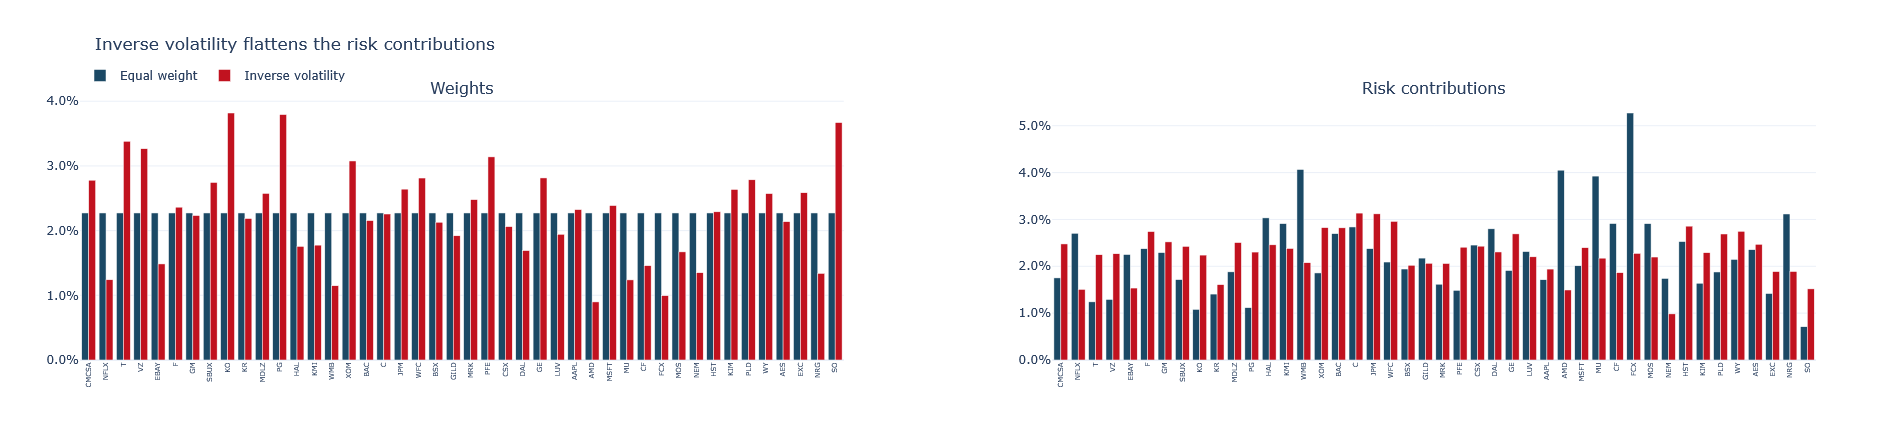

Inverse-vol weighting narrows the risk spread substantially, using nothing but each
stock's own volatility. No expected returns, no optimiser, no matrix inversion.
Remember how well it does here -- in Lecture 3b it becomes a benchmark that is
embarrassingly hard to beat.


In [12]:
fig = make_subplots(rows=1, cols=2, subplot_titles=("Weights", "Risk contributions"),
                    horizontal_spacing=0.12)
for i, (name, w) in enumerate(portfolios.items()):
    rc = risk_contributions(w.values, returns)
    fig.add_trace(go.Bar(x=universe, y=w.values, name=name,
                         marker_color=AIRM_COLOURS[i], legendgroup=name), 1, 1)
    fig.add_trace(go.Bar(x=universe, y=rc.values, name=name, showlegend=False,
                         marker_color=AIRM_COLOURS[i], legendgroup=name), 1, 2)
fig.update_layout(title="Inverse volatility flattens the risk contributions",
                  template=AIRM_TEMPLATE, height=440, barmode="group",
                  legend=dict(orientation="h", y=1.15))
fig.update_xaxes(tickangle=-90, tickfont=dict(size=7))
fig.update_yaxes(tickformat=".1%")
fig.show()

print("Inverse-vol weighting narrows the risk spread substantially, using nothing but each")
print("stock's own volatility. No expected returns, no optimiser, no matrix inversion.")
print("Remember how well it does here -- in Lecture 3b it becomes a benchmark that is")
print("embarrassingly hard to beat.")

---

## 7. The verdict, and what it sets up

> **"Diversification reduces risk."**

**True, and now quantified.** Going from one stock to 44 cut volatility by roughly half.
But the reduction is not unlimited: it stops at $\sigma\sqrt{\rho}$, most of the available
benefit arrives within about ten stocks (86% of it), and because our 44 stocks contain no
genuine hedge, that floor sits high — at 13.8% annualised volatility.

Which leaves exactly one question, and it is Lecture 3b's:

> Everything so far used *fixed* weights — equal, or inverse-volatility. Could we do better
> by **choosing** the weights optimally?

The answer is a beautiful piece of mathematics from 1952 that wins a Nobel Prize, and then
fails so badly in practice that a naive equal-weighted portfolio beats it out of sample.
Understanding *why* is what makes shrinkage, denoising and clustering — the AI content of
Lecture 3c — worth learning.

### What breaks in production

**Correlations are not stable.** We computed one number per pair over five years. In a
crisis, correlations jump towards 1 exactly when you need diversification most. Our floor is
therefore an *optimistic* estimate. Lecture 6 measures this.

**Volatility is not stable either.** Inverse-vol weighting uses trailing volatility to set
tomorrow's weights, which works only because volatility is persistent. It is, quite strongly
— that persistence is what Lecture 10 forecasts.

**No costs, no constraints.** Rebalancing 44 positions to hold weights exactly costs money,
and many mandates cap position sizes or sector exposures. Lecture 3c adds both.

**Equal weight is not free either.** It requires continuous rebalancing to *stay* equal, and
it systematically tilts towards small, illiquid names.

---

## 8. Exercises

### Core

**C1 — Find the free lunch.** Using the slider in Section 2, estimate the correlation at
which a 50/50 blend of assets A and B becomes *less* volatile than asset A alone. Verify
your answer with the minimum-variance formula in the maths box.

**C2 — How many stocks is enough?** Modify the Section 4 experiment to report how many
stocks are needed to capture 90% of the available risk reduction. Does the answer change if
you restrict the universe to a single sector? Explain why.

**C3 — Break the floor.** The floor is $\sigma\sqrt{\bar\rho}$. Find the pair of stocks in
our universe with the lowest correlation, and build an equally weighted portfolio from just
those two. Is its volatility below the 44-stock floor? What does that tell you about
*selection* versus *quantity*?

**C4 — Sector concentration.** Rebuild the universe with `PER_SECTOR = 12` but only three
sectors. Recompute the average correlation and the floor. How much diversification did you
lose by concentrating, even though the number of stocks barely changed?

### Stretch

**S1 — Time-varying correlation.** Compute the average pairwise correlation in rolling
one-year windows and plot it. When was diversification most and least effective? Overlay the
implied floor on the same chart.

**S2 — Derive the floor.** Starting from $\sigma_p^2 = w^\top\Sigma w$ with equal weights,
uniform variance $\sigma^2$ and uniform correlation $\rho$, derive
$\sigma_p^2 = \sigma^2/N + (1-1/N)\rho\sigma^2$. Then show that the marginal benefit of the
$N$-th asset falls as $1/N^2$.

**S3 — True risk parity.** Implement risk parity properly: find weights such that all risk
contributions equal $1/N$, using `scipy.optimize.minimize` on the squared deviations from
equal contribution. How different are the weights from inverse volatility, and how much
does the difference depend on the correlation structure?

**S4 — The negative-correlation hunt.** Only 6 of our 946 equity pairs were negatively
correlated, and none below −0.06. Add a bond or gold proxy (any low-correlation series you can obtain) and recompute the
floor. How much does one genuinely diversifying asset buy you, compared with adding twenty
more equities?

---

## Summary

| | |
|---|---|
| **The claim** | "Diversification reduces risk" |
| **The verdict** | True, but bounded: risk falls to $\sigma\sqrt{\rho}$ and no further |
| **The number to remember** | ~10 stocks capture most of the available benefit; 44 stocks cut volatility roughly in half |

1. **Return is linear in weights; risk is not.** All of portfolio construction lives in
   that gap.
2. **Correlation, not volatility, drives portfolio risk** — and correlation has real
   structure (sectors), which Lecture 3c will exploit.
3. **There is a diversification floor** at $\sigma\sqrt{\rho}$. Since no pair of our stocks
   was negatively correlated, that floor is high.
4. **Weights are not risks.** Equal weighting produced a 7.4-to-1 spread in risk
   contributions; inverse-volatility weighting flattened it using no expected returns at all.

**Next**, in Lecture 3b, we stop choosing weights by recipe and start *optimising* them —
and discover that the optimiser's greatest talent is maximising estimation error.